In [1]:
import os
import sys
import scipy
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import scipy.io as sio
import scanpy.external as sce
import matplotlib.pyplot as plt
import re
import anndata as ad
import statistics
import tempfile
import sklearn
import cosg
import celltypist
sc._settings.ScanpyConfig.n_jobs=24
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=400,
    facecolor = 'white', figsize=(8,8), format='png')
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 100)
import warnings
warnings.filterwarnings('ignore')

In [2]:
sc.logging.print_header()

Package,Version
scipy,1.15.2
numpy,2.2.5
pandas,2.2.3
scanpy,1.11.1
seaborn,0.13.2
matplotlib,3.9.2
anndata,0.11.4
scikit-learn,1.5.2
cosg,1.0.1
celltypist,1.6.3


In [3]:
marker_dict2={
    'B': ['MS4A1','CD79A','BANK1','CD22','FCRL1','TCL1A','FCER2'],
    'Plasma|Plasmablast':['TNFRSF17','JCHAIN','IGHA1','MZB1','XBP1'],
    
    'CD4+ T':['TCF7','MAL','IL7R','RCAN3','DGKA',],
    'CD8+ T':['CD8A','CD8B','LINC02446','CCL5','THEMIS','KLRK1'],
    'MAIT':['SLC4A10','TRAV1-2','KLRB1',],
    'Platelet':['TUBB1','CAVIN2','PF4',],
    'NKT':['TRAV24','TRBV28','CLDND1','DZIP3','ORM2','GPRC5D','FGFR2'],
    'NK': ['KLRF1', 'SPON2','GNLY', 'GZMB','PRF1','KLRD1','TYROBP'],
    'non-NK ILC': ['FSTL4', 'HPGDS','PKIB', 'PTGDR2','SCART1'],
    'γδ T':['TRDC','TRDV2','TRGC1','TRGC2','TRGV9','KLRD1','CCL5','KLRC1'],
    
    'HPSC':['CD34','NPR3','SMIM24','SPINK2','CRHBP','EMP1','ACY3','NYNRIN'], 
    'DC':['ENHO','CLEC10A','CD1C','FCER1A','FLT3','HLA-DQA1'],
    'Classical monocyte':['FCN1','VCAN','LRP1','CD14','MS4A6A','CST3'],
    'Non-classical monocyte':['CDKN1C','CSF1R','CKB','NEURL1','LYPD2','AIF1'],
    'CEACAM8+ Neutrophil':['CEACAM8','LCN2','BPI','LTF','CRISP3','CEACAM6'],
    'CEACAM8- Neutrophil':['CSF3R','NAMPT','FCGR3B','IFITM2','SLC25A37','FCGR3B', 'S100A9'],
    'Eosinophil':['EPX', 'SIGLEC8', 'IL5RA'],
    'Basophil':['HDC','GATA2','MS4A2','AKAP12','CLC','IL4','RHOXF1P1',], 
    'Mast':['STXBP6', 'PPIL6', 'KIT',],
    'pDC':['SERPINF1','PTPRS','LILRA4','TNFRSF21','PLD4','SCT'],
    
    'Proliferative signal':['MKI67','TOP2A','STMN1'],
}

In [4]:
def check_dict_duplicates(dict):
    seen = set()
    dup = any(item in seen or seen.add(item) for lst in dict.values() for item in lst)
    if dup==False:
        return '无重复'
    else:
        return '有重复'

In [5]:
obj_path = '/home/liyanguo/MyImmuCell/04_MyImmuCell_TOTALVI/'
sc.settings.figdir = obj_path

In [6]:
dataset = "low_nCount_RNA"

# 1. Load data after cluster (raw count)

In [7]:
print(dataset)

low_nCount_RNA


In [8]:
adata = sc.read_h5ad(f'{obj_path}scRNA_MyImmuCell_{dataset}_HVG.h5ad',backed='r')

# 2. Set leiden group and identify cell identity

In [9]:
groupby = "L1_leiden_TOTALVI_2"

In [10]:
adata.obs[groupby].value_counts()

L1_leiden_TOTALVI_2
21    3185231
5     2366888
27    2084755
9     2058448
23    1897361
20    1746275
22    1659070
18    1655656
15    1592522
26    1202881
19    1109607
17    1024580
13    1011686
7      999446
8      989616
10     864893
24     785352
14     769382
12     739354
2      656389
0      623339
25     559671
3      559089
11     513717
16     503244
6      479773
4      439704
30     102892
1       89795
29      89772
28      49869
Name: count, dtype: int64

In [11]:
adata

AnnData object with n_obs × n_vars = 32410257 × 2000 backed at '/home/liyanguo/MyImmuCell/04_MyImmuCell_TOTALVI/scRNA_MyImmuCell_low_nCount_RNA_HVG.h5ad'
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Reference_Atlas_L1L2_mv', 'Reference_Atlas_L1L2_pl', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'percent.mt', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'mapping.score', 'scDblFinder.class', 'High_quality', 'L1_leiden_TOTALVI_2', 'L1_leiden_TOTALVI_3', 'L1_leiden_TOTALVI_4'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances

In [12]:
cell_index = celltypist.samples.downsample_adata(adata,mode = 'each', n_cells = 30000,
                                                 by = 'L1_leiden_TOTALVI_2',
                                                 return_index = True,random_state=0)

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

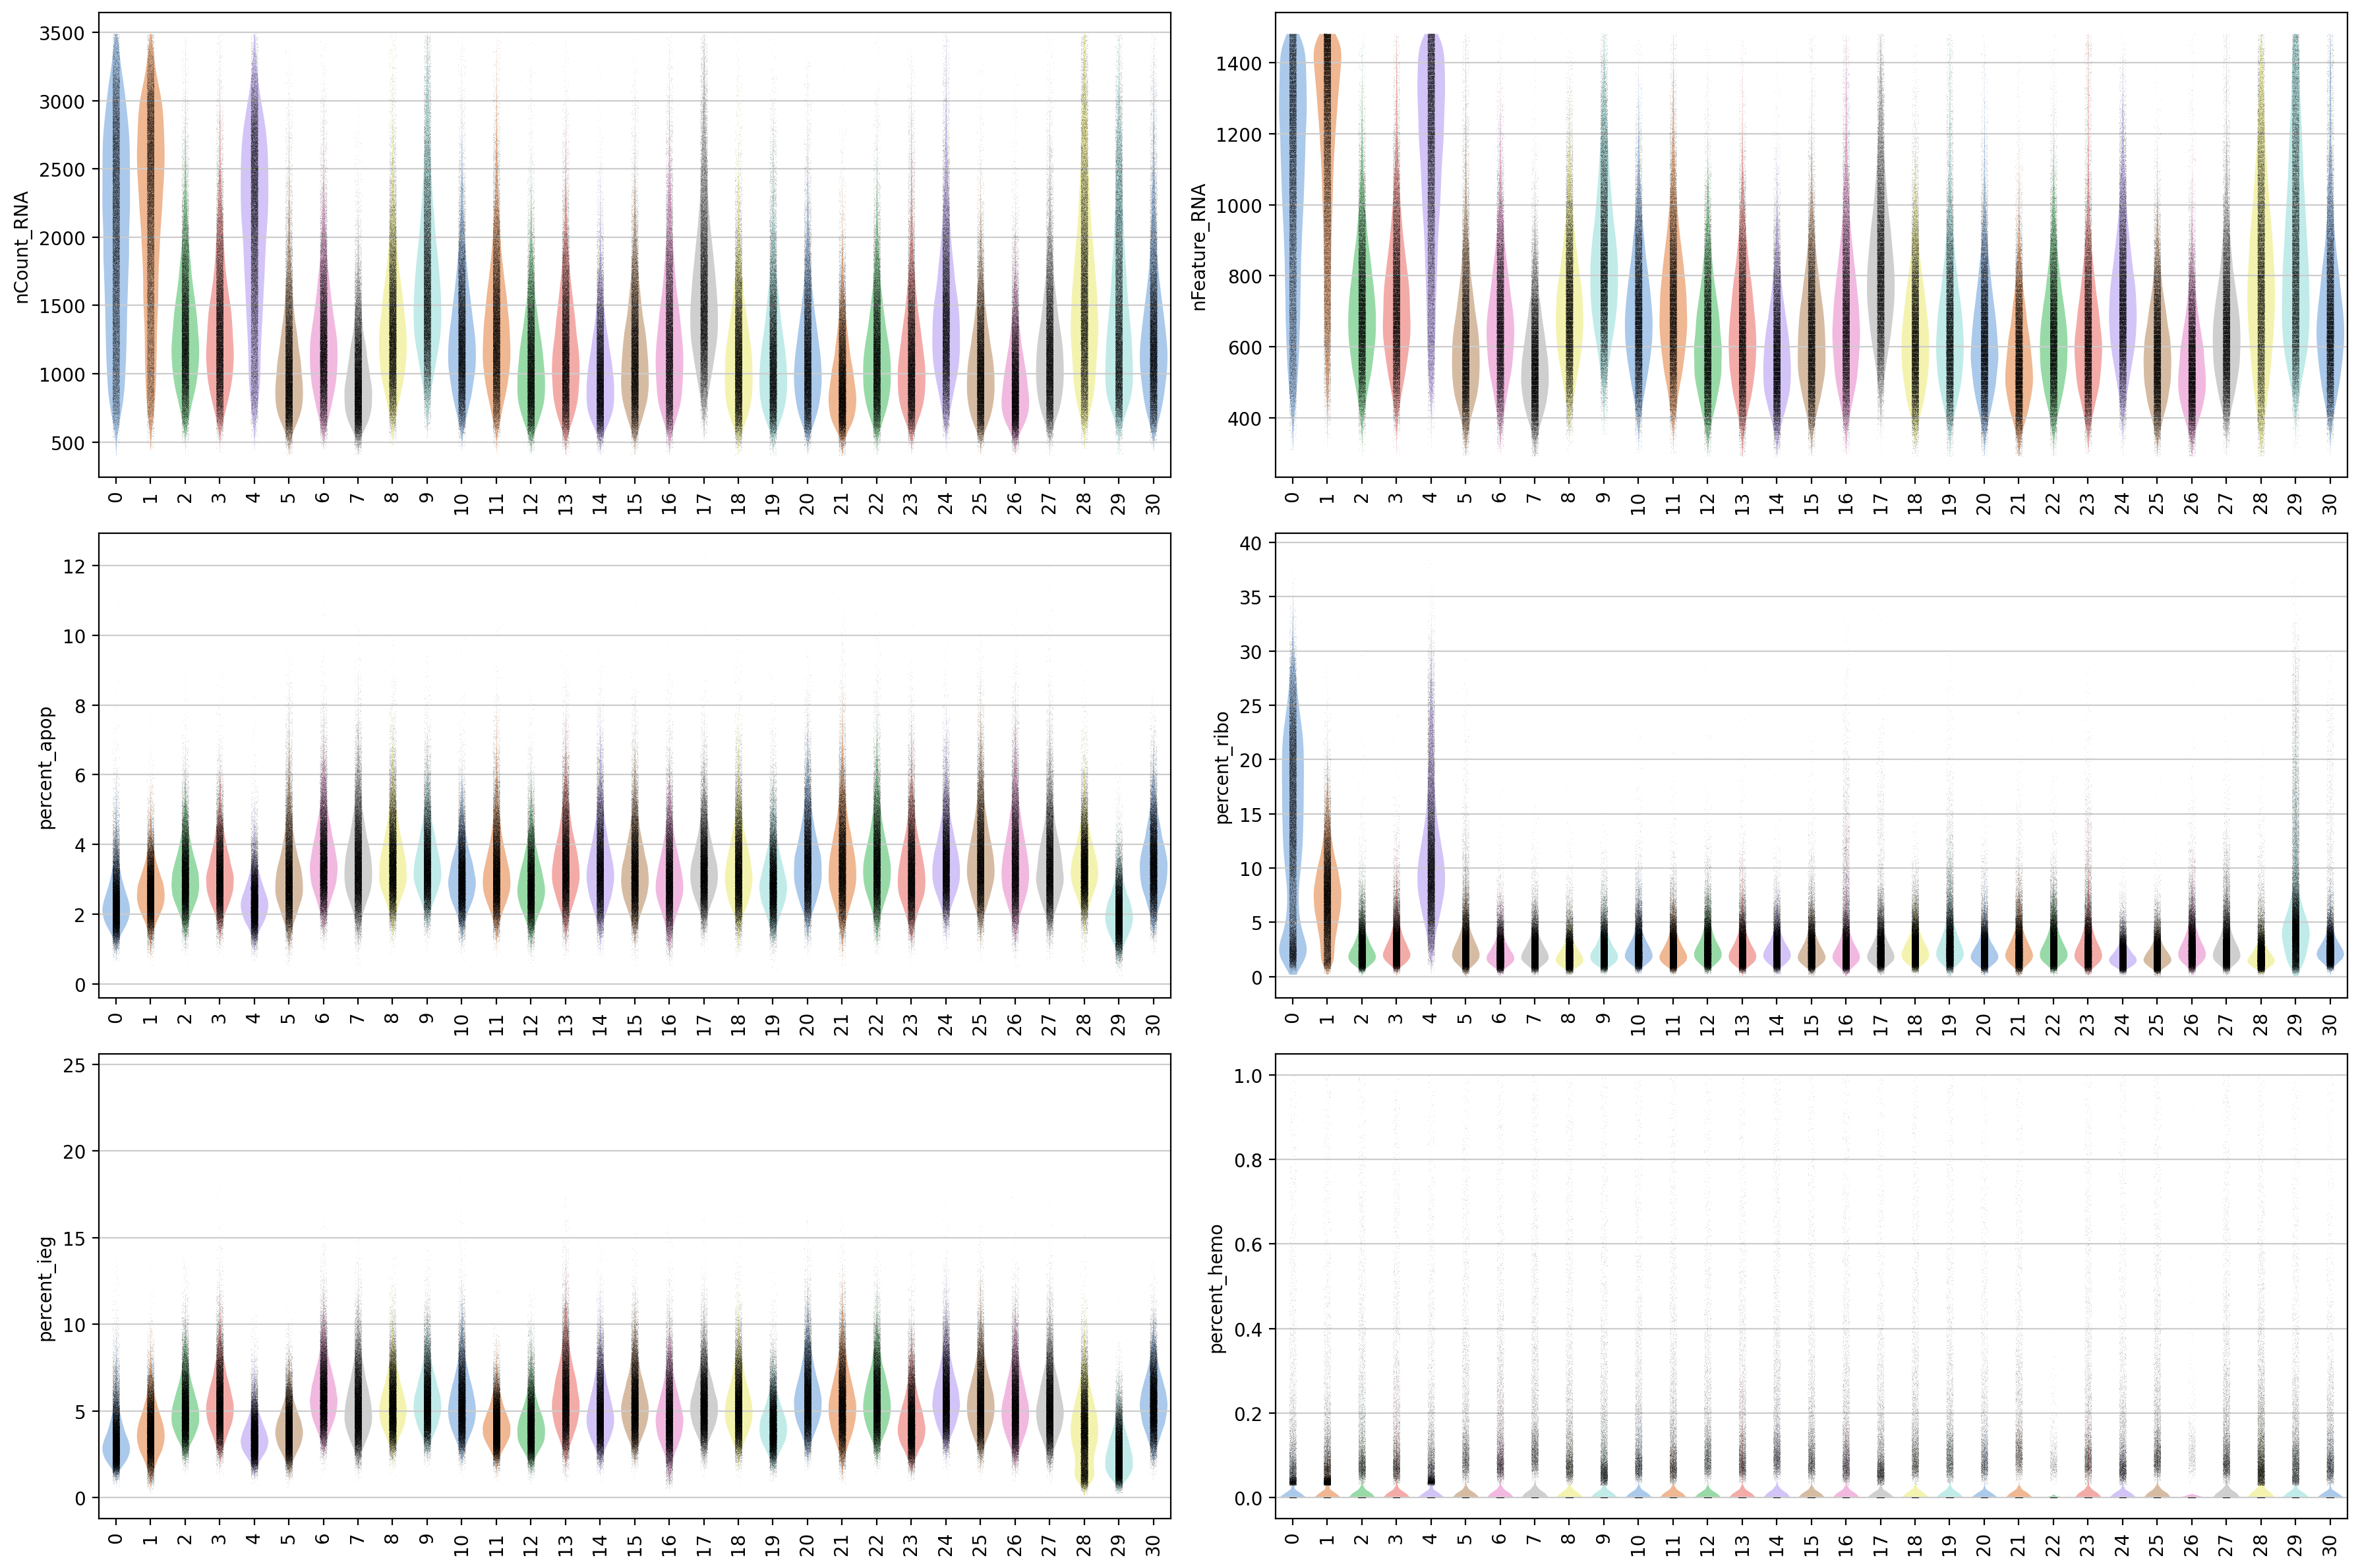

In [13]:
#数据簇间信息比较
fig, axs = plt.subplots(3, 2, figsize=(18, 12),constrained_layout=True)
sc.pl.violin(adata[cell_index], keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata[cell_index], keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata[cell_index], keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)
sc.pl.violin(adata[cell_index], keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{dataset}_{groupby}_TOTALVI_L1_metadata')

## 2.1 Clinical and Celltypist and Azimuth

In [14]:
xlsx = pd.ExcelWriter(f"{obj_path}{dataset}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class','Phase',
              'Reference_Atlas_L1L2_pl','Reference_Atlas_L1L2_mv',
              'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l1', 'predicted.celltype.l2',
              'predicted.celltype.l3']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

## 2.2 TCR BCR based annotation

In [15]:
#根据TCR识别部分细胞；TCR作为充分非必要条件
data_tcr = pd.read_csv("/home/liyanguo/MyImmuCell/02_Read_QC/scTCR_MyImmuCell.csv",index_col=0,usecols=[0,1])
data_bcr = pd.read_csv("/home/liyanguo/MyImmuCell/02_Read_QC/scBCR_MyImmuCell.csv",index_col=0,usecols=[0,1])

In [16]:
adata.obs = adata.obs.join(data_tcr, how='left')#TCR

In [17]:
adata.obs = adata.obs.join(data_bcr, how='left',rsuffix='_BCR')#BCR

In [18]:
adata.obs.receptor_type.value_counts()

receptor_type
TCR    1705952
Name: count, dtype: int64

In [19]:
adata.obs.receptor_type_BCR.value_counts()

receptor_type_BCR
BCR    617621
Name: count, dtype: int64

In [20]:
xlsx = pd.ExcelWriter(f"{obj_path}{dataset}_freq_table_tcrbcr.xlsx")
for group in ['receptor_type', 
              'receptor_type_BCR',]:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    freq_table_multi.to_excel(xlsx,sheet_name=group)
xlsx.close()

## 2.3 Source of Doublet

In [21]:
data = adata.obs.loc[:,[groupby,'scDblFinder.class','receptor_type','receptor_type_BCR',
                        'Reference_Atlas_L1L2_mv','Immune_All_High',
                        'AIFI_L1','predicted.celltype.l1']]

In [22]:
xlsx = pd.ExcelWriter(f"{obj_path}{dataset}_scDblFinder_freq_table.xlsx")
for i in ["9",'17',]:
    tmp = data[data[groupby].isin([i])]
    for group in ['Reference_Atlas_L1L2_mv','receptor_type','receptor_type_BCR',
                  'Immune_All_High',
                  'AIFI_L1','predicted.celltype.l1']:
        freq_table_multi = tmp.groupby(['scDblFinder.class', group]).size()
        pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=f"{i}_{group}")
    del tmp
xlsx.close()

In [23]:
#The results indicate that the source of doublet cells is not T/B/Myeloid cells in the auto-annotation results.

In [24]:
#The results indicate that one-tenth of the doublet cells are derived from Neu that detect TCR and BCR.

# 3. Cell_dict: fill in the clusters that belong to each cell type

In [25]:
# Downstream strategies:
# For clusters with mixtures, perform refinement.
# For clusters without mixtures, merging them with refinement in step 1 and PBMC mature Neu.
# Final results.

In [64]:
cell_dict = {'Basophil':['29'],#KIT-

             'Platelet':['28'],#
             
             'CEACAM8- Neutrophil':['2','3','5','6','7','8','9','10',
                                    '11','12','13','14','15','16','17','18','19',
                                    '20','21','22','23','24','25','26','27','30',
                                   ],
             'Doublet':['0','4',#T|NK|CEACAM8- Neutrophil; UMI high
                       '1'#Classical monocyte|CEACAM8- Neutrophil;  UMI high
                       ],
            }

In [65]:
cell_dict.values()

dict_values([['29'], ['28'], ['2', '3', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '30'], ['0', '4', '1']])

In [66]:
check_dict_duplicates(cell_dict)

'无重复'

In [68]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L1_L2'] = i

In [69]:
(adata.obs['Celltype_L1_L2'].isna()).value_counts()

Celltype_L1_L2
False    32410257
Name: count, dtype: int64

In [70]:
adata.obs.loc[adata.obs['receptor_type']=='TCR','Celltype_L1_L2']="Doublet"
adata.obs.loc[adata.obs['receptor_type_BCR']=='BCR','Celltype_L1_L2']="Doublet"

In [71]:
(adata.obs['Celltype_L1_L2']).value_counts()

Celltype_L1_L2
CEACAM8- Neutrophil    29305615
Doublet                 2980852
Basophil                  76474
Platelet                  47316
Name: count, dtype: int64

In [72]:
adata.strings_to_categoricals()

... storing 'Celltype_L1_L2' as categorical


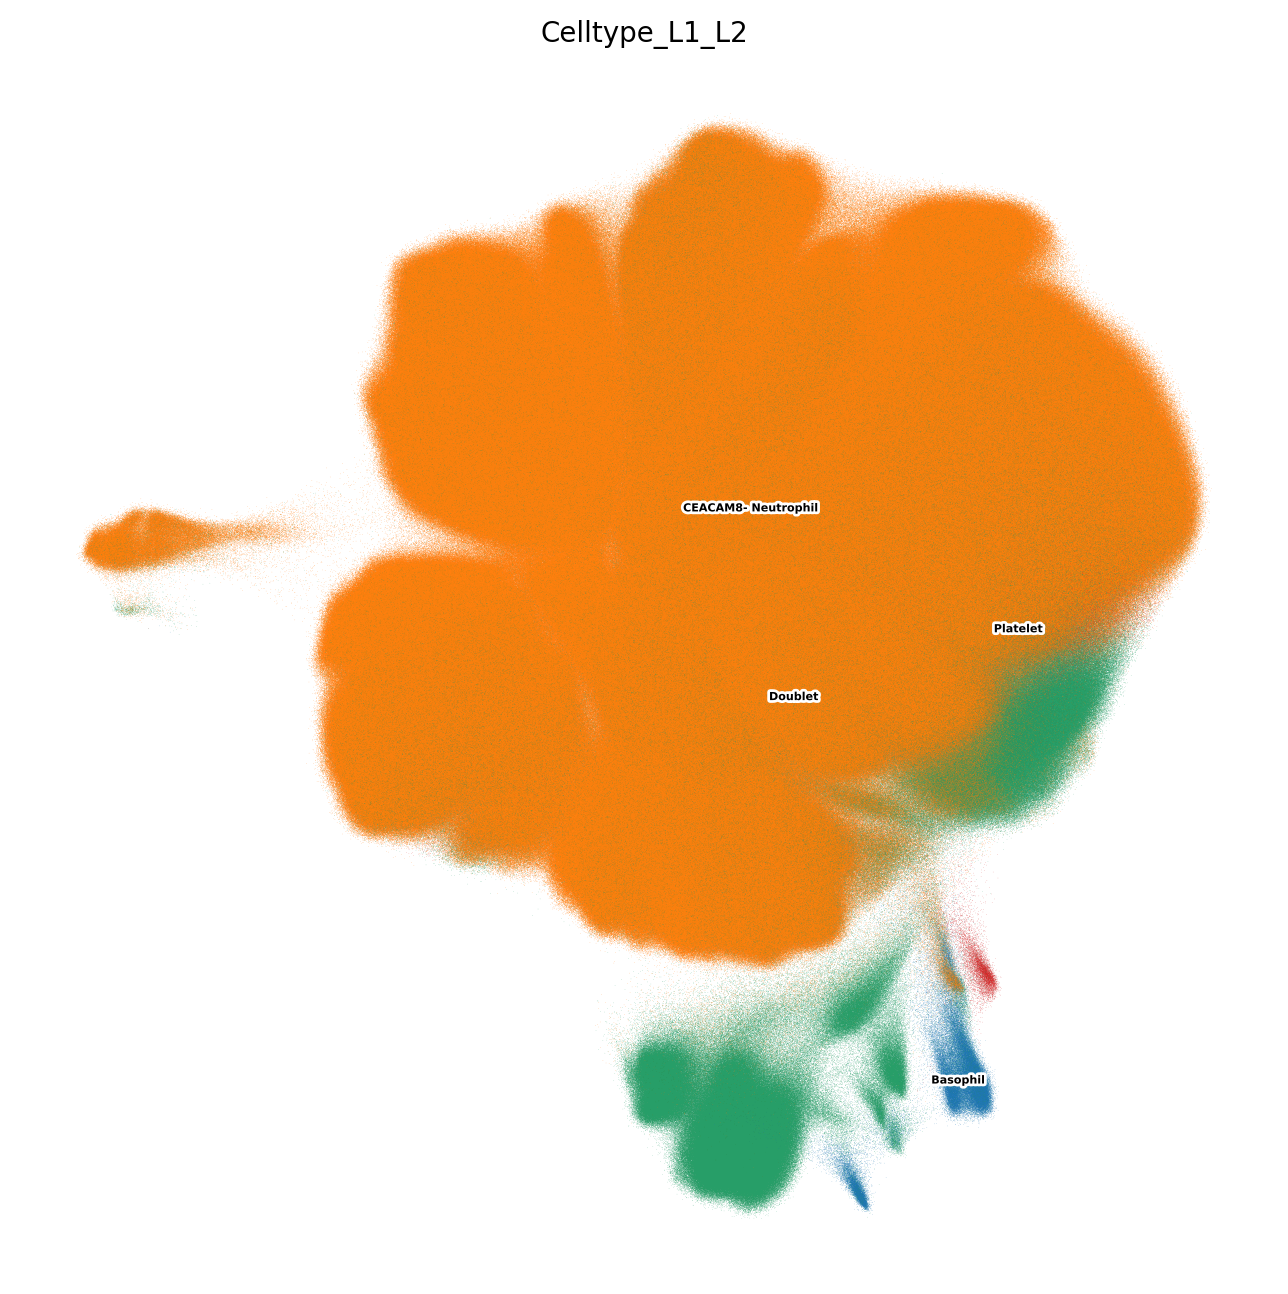

In [73]:
sc.pl.umap(adata, color=['Celltype_L1_L2'],
           save=f'_{dataset}_Celltype_L1_L2',
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=0.1,
           legend_loc='on data')

# 4. Level1 and Level2 Refine, Round1.

In [74]:
adata.obs.Celltype_L1_L2.value_counts()

Celltype_L1_L2
CEACAM8- Neutrophil    29305615
Doublet                 2980852
Basophil                  76474
Platelet                  47316
Name: count, dtype: int64

In [75]:
CEACAM8_Neg_Neutrophil=adata[adata.obs['Celltype_L1_L2'].isin(['CEACAM8- Neutrophil']), :]
CEACAM8_Neg_Neutrophil.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
CEACAM8- Neutrophil    29305615
Name: count, dtype: int64

In [82]:
Platelet=adata[adata.obs['Celltype_L1_L2'].isin(['Platelet']), :]
Platelet.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
Platelet    47316
Name: count, dtype: int64

In [77]:
Basophil=adata[adata.obs['Celltype_L1_L2'].isin(['Basophil']), :]
Basophil.obs['Celltype_L1_L2'].value_counts()

Celltype_L1_L2
Basophil    76474
Name: count, dtype: int64

In [78]:
L2_refine_path='/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/'

In [79]:
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/CEACAM8_Neg_Neutrophil', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/Platelet', exist_ok=True)
os.makedirs(f'{L2_refine_path}/Level2_Refine_R1/Basophil', exist_ok=True)

## Save cell index

In [80]:
indices_CEACAM8_Neg_Neutrophil = CEACAM8_Neg_Neutrophil.obs.loc[:,['Celltype_L1_L2','receptor_type','receptor_type_BCR',groupby]]
indices_CEACAM8_Neg_Neutrophil.to_csv(f"{L2_refine_path}/Level2_Refine_R1/CEACAM8_Neg_Neutrophil/R1_indices_CEACAM8_Neg_Neutrophil.csv")

In [83]:
indices_Platelet = Platelet.obs.loc[:,['Celltype_L1_L2','receptor_type','receptor_type_BCR',groupby]]
indices_Platelet.to_csv(f"{L2_refine_path}/Level2_Refine_R1/Platelet/R1_indices_Platelet.csv")

In [84]:
indices_Basophil = Basophil.obs.loc[:,['Celltype_L1_L2','receptor_type','receptor_type_BCR',groupby]]
indices_Basophil.to_csv(f"{L2_refine_path}/Level2_Refine_R1/Basophil/R1_indices_Basophil.csv")